In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
import numpy as np
import pandas as pd

In [37]:
path = "/content/drive/MyDrive/NYC Taxi Trips/NYC.csv"
df = pd.read_csv(path)

In [38]:
df.head(5)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [39]:
df = df.drop(columns=["id" , "vendor_id" ,"dropoff_datetime" ])
df.head(5)

,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,2016-03-14 17:24:55,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,2016-06-12 00:43:35,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,2016-01-19 11:35:24,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,2016-04-06 19:32:31,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,2016-03-26 13:30:55,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [40]:
numirics = df.select_dtypes(include=['int64' , 'float64'])
categoricals = df.select_dtypes(include=['object'])

for col in numirics.columns:
    print(df[[col , "trip_duration"]].corr())

                 passenger_count  trip_duration
passenger_count         1.000000       0.008471
trip_duration           0.008471       1.000000
                  pickup_longitude  trip_duration
pickup_longitude          1.000000       0.026542
trip_duration             0.026542       1.000000
                 pickup_latitude  trip_duration
pickup_latitude         1.000000      -0.029204
trip_duration          -0.029204       1.000000
                   dropoff_longitude  trip_duration
dropoff_longitude           1.000000       0.014678
trip_duration               0.014678       1.000000
                  dropoff_latitude  trip_duration
dropoff_latitude          1.000000      -0.020677
trip_duration            -0.020677       1.000000
               trip_duration  trip_duration
trip_duration            1.0            1.0
trip_duration            1.0            1.0


In [41]:
missing = df.isnull().sum()
print(missing[missing > 1 ])

Series([], dtype: int64)


## **Most important part: Feature engineering**

Haversine Method

In [42]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c

**apply** **FE**
*italicized text*

In [43]:
df["distance KM"] = haversine(df["pickup_latitude"] , df["pickup_longitude"] , df["dropoff_latitude"] , df["dropoff_longitude"])

In [44]:
df["day"] = pd.to_datetime(df["pickup_datetime"]).dt.day_name()
df["month"] = pd.to_datetime(df["pickup_datetime"]).dt.month
df["year"] = pd.to_datetime(df["pickup_datetime"]).dt.year
df["hour"] = pd.to_datetime(df["pickup_datetime"]).dt.hour
df["minute"] = pd.to_datetime(df["pickup_datetime"]).dt.minute
df["WeekEnd"] = pd.to_datetime(df["pickup_datetime"]).dt.dayofweek
df["WeekEnd"] = df["WeekEnd"].apply(lambda x: 1 if x >= 5 else 0)

# **OUTLIERS Detection**

In [45]:
numirics = df.select_dtypes(include=['int64' , 'float64'])
categoricals = df.select_dtypes(include=['object'])
Q1 = numirics.quantile(0.25)
Q2 = numirics.quantile(0.50)
Q3 = numirics.quantile(0.75)
IQR = Q3-Q1
upper = Q3 + 1.5 * IQR
lower = Q1 - 1.5 * IQR
outliers = (numirics < lower) | (numirics > upper)
print(outliers.sum())

passenger_count      154830
pickup_longitude      84322
pickup_latitude       52743
dropoff_longitude     77969
dropoff_latitude      71990
trip_duration         74220
distance KM          140673
WeekEnd                   0
dtype: int64


**Outliers Handling**

In [46]:
df["distance KM"].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

,distance KM
count,1.458644e+06
mean,3.440864e+00
std,4.296538e+00
min,0.000000e+00
50%,2.093717e+00
90%,7.630836e+00
95%,1.101931e+01
99%,2.078752e+01
99.5%,2.155737e+01
99.9%,2.476676e+01


In [47]:
df = df[df["distance KM"] <= 30]

In [48]:
df['trip_duration'].describe(percentiles=[0.90, 0.95, 0.99, 0.995, 0.999])

,trip_duration
count,1.458071e+06
mean,9.583696e+02
std,5.236975e+03
min,1.000000e+00
50%,6.620000e+02
90%,1.632000e+03
95%,2.100000e+03
99%,3.426000e+03
99.5%,4.120000e+03
99.9%,8.512700e+04


In [49]:
df = df[df['trip_duration'] <= 4120]

# **EDA**

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
df.drop(
    columns=[
        "pickup_longitude" ,
        "pickup_latitude" ,
        "dropoff_longitude" ,
        "dropoff_latitude" ,
        "year"]
    ,inplace=True
    )

In [52]:
df.head()

,pickup_datetime,passenger_count,store_and_fwd_flag,trip_duration,distance KM,day,month,hour,minute,WeekEnd
0,2016-03-14 17:24:55,1,N,455,1.498521,Monday,3,17,24,0
1,2016-06-12 00:43:35,1,N,663,1.805507,Sunday,6,0,43,1
2,2016-01-19 11:35:24,1,N,2124,6.385098,Tuesday,1,11,35,0
3,2016-04-06 19:32:31,1,N,429,1.485498,Wednesday,4,19,32,0
4,2016-03-26 13:30:55,1,N,435,1.188588,Saturday,3,13,30,1


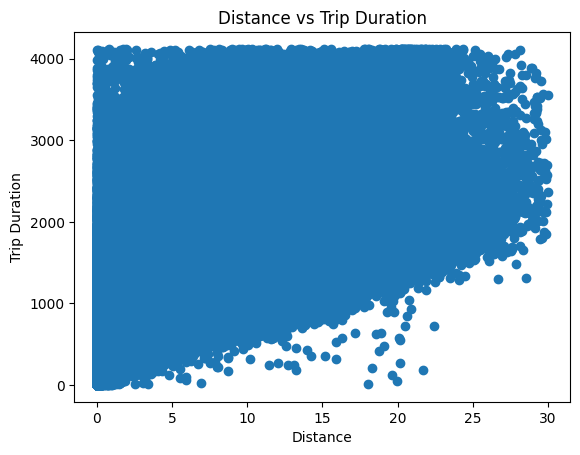

In [53]:
Target = df['trip_duration']
plt.scatter(df['distance KM'] , Target )
plt.title('Distance vs Trip Duration')
plt.xlabel('Distance')
plt.ylabel('Trip Duration')
plt.show()

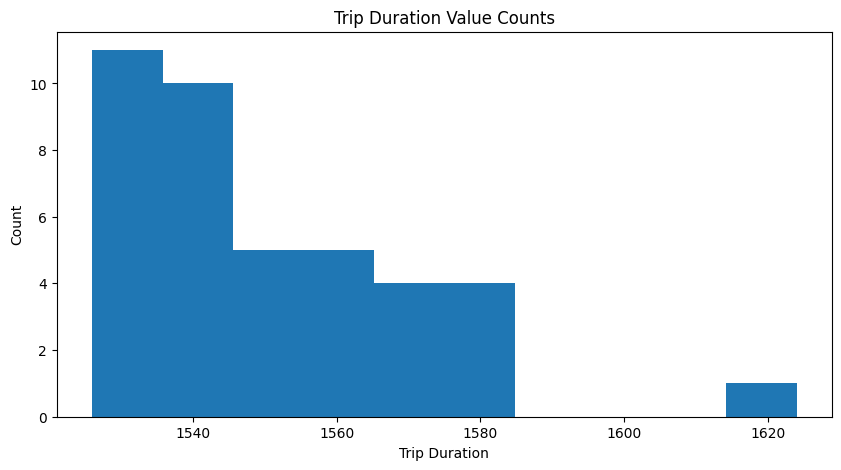

In [54]:
df.trip_duration.value_counts().nlargest(40).plot(kind='hist', figsize=(10,5))
plt.title('Trip Duration Value Counts')
plt.xlabel('Trip Duration')
plt.ylabel('Count')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

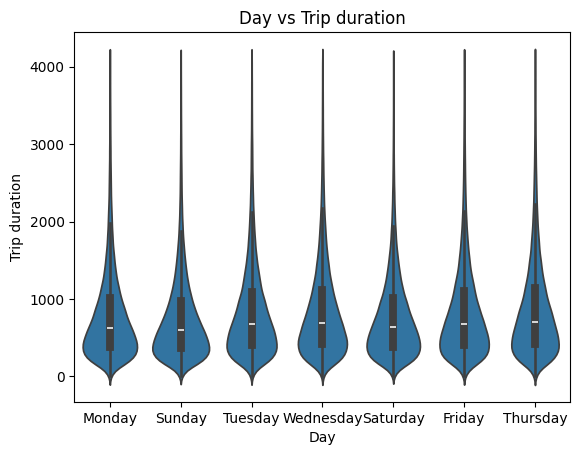

In [55]:
sns.violinplot(data=df, x="day", y="trip_duration")
plt.title('Day vs Trip duration')
plt.xlabel('Day')
plt.ylabel('Trip duration')
plt.show

In [56]:
df.groupby("day")["trip_duration"].median()

,trip_duration
day,
Friday,681.0
Monday,627.0
Saturday,635.0
Sunday,600.0
Thursday,705.0
Tuesday,675.0
Wednesday,690.0


In [57]:
df.groupby("day")["trip_duration"].mean().sort_values(ascending=False)


,trip_duration
day,
Thursday,875.393090
Wednesday,859.603333
Friday,845.204980
Tuesday,840.053929
Monday,793.430877
Saturday,773.025099
Sunday,754.388197


In [58]:
df.groupby("day")["distance KM"].mean()

,distance KM
day,
Friday,3.305355
Monday,3.486597
Saturday,3.299569
Sunday,3.685731
Thursday,3.323744
Tuesday,3.275938
Wednesday,3.257483


## **Encoding**:

In [59]:
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].map({'Y':1 , 'N':0})

### **ONE HOT ENCODER**

In [60]:
df.drop(columns=["pickup_datetime"] , inplace=True)
df = pd.get_dummies(
    df,
    columns=["day"],
    drop_first=True)
df.head(5)

,passenger_count,store_and_fwd_flag,trip_duration,distance KM,month,hour,minute,WeekEnd,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
0,1,0,455,1.498521,3,17,24,0,True,False,False,False,False,False
1,1,0,663,1.805507,6,0,43,1,False,False,True,False,False,False
2,1,0,2124,6.385098,1,11,35,0,False,False,False,False,True,False
3,1,0,429,1.485498,4,19,32,0,False,False,False,False,False,True
4,1,0,435,1.188588,3,13,30,1,False,True,False,False,False,False


**Correlations After Encoding Processes**

,passenger_count,store_and_fwd_flag,trip_duration,distance KM,month,hour,minute,WeekEnd,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday
passenger_count,1.000000,-0.021853,0.015417,0.011255,-0.002388,0.009107,0.000970,0.028423,-0.009078,0.020815,0.015770,-0.008454,-0.008765,-0.009760
store_and_fwd_flag,-0.021853,1.000000,0.023959,0.026439,0.000160,0.002353,0.000113,-0.004660,0.002264,-0.002795,-0.003236,0.002066,0.000017,0.000711
trip_duration,0.015417,0.023959,1.000000,0.765889,0.055436,0.032736,-0.010977,-0.059270,-0.017575,-0.033542,-0.043268,0.037290,0.012390,0.025815
distance KM,0.011255,0.026439,0.765889,1.000000,0.012587,-0.018768,-0.009109,0.018488,0.011813,-0.007962,0.032893,-0.005207,-0.010082,-0.012295
month,-0.002388,0.000160,0.055436,0.012587,1.000000,-0.003687,-0.001015,-0.007919,-0.000153,-0.006962,-0.003170,0.013904,0.008857,0.014258
hour,0.009107,0.002353,0.032736,-0.018768,-0.003687,1.000000,-0.002900,-0.090398,0.022733,-0.031250,-0.086950,0.031086,0.031566,0.029266
minute,0.000970,0.000113,-0.010977,-0.009109,-0.001015,-0.002900,1.000000,0.000482,0.000500,0.002790,-0.002297,0.001193,-0.002348,-0.000744
WeekEnd,0.028423,-0.004660,-0.059270,0.018488,-0.007919,-0.090398,0.000482,1.000000,-0.242968,0.668456,0.622075,-0.265419,-0.254268,-0.259471
day_Monday,-0.009078,0.002264,-0.017575,0.011813,-0.000153,0.022733,0.000500,-0.242968,1.000000,-0.162413,-0.151144,-0.161061,-0.154294,-0.157452
day_Saturday,0.020815,-0.002795,-0.033542,-0.007962,-0.006962,-0.031250,0.002790,0.668456,-0.162413,1.000000,-0.166497,-0.177421,-0.169967,-0.173445


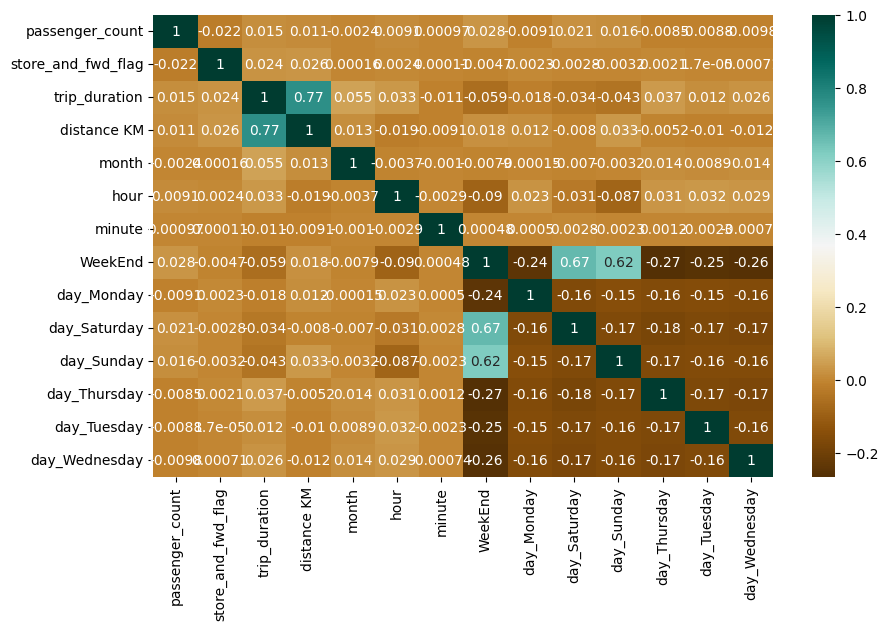

In [61]:
plt.figure(figsize=(10,6))
corrs = df.corr()
sns.heatmap(corrs, cmap="BrBG" , annot = True)
corrs

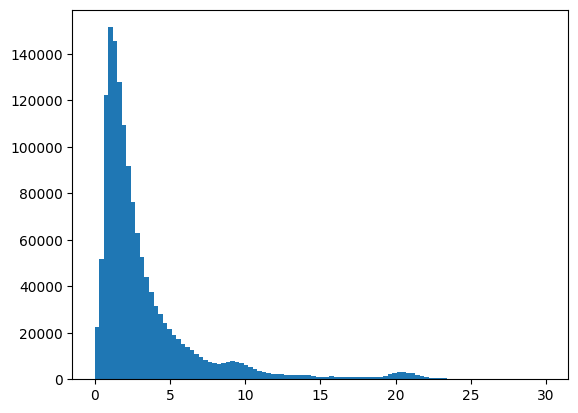

In [62]:
import matplotlib.pyplot as plt

plt.hist(df["distance KM"], bins=100)
plt.show()

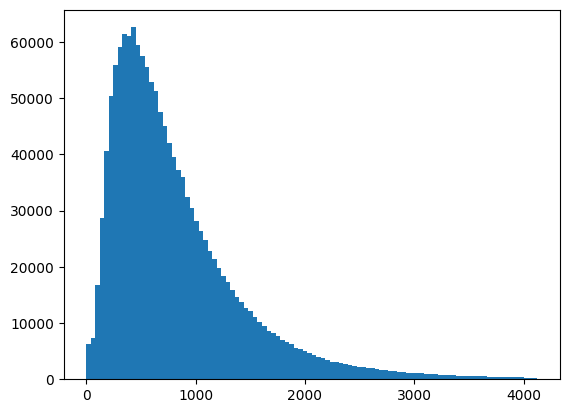

In [63]:
plt.hist(df["trip_duration"], bins=100)
plt.show()

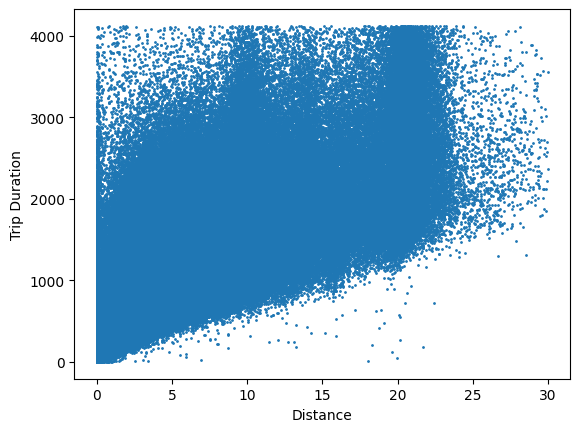

In [64]:
plt.scatter(df["distance KM"], df["trip_duration"], s=1)
plt.xlabel("Distance")
plt.ylabel("Trip Duration")
plt.show()

# **Data Splitting**

In [65]:
X = df.drop(columns=["trip_duration"])
y = df["trip_duration"]

In [66]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **AI Model Selection**

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [68]:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),

    # "Random Forest": RandomForestRegressor(
    #     n_estimators=150,
    #     max_depth=15,
    #     random_state=42,
    #     n_jobs=-1
    # ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("MSE :", mean_squared_error(y_test, y_pred))
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("R2  :", r2_score(y_test, y_pred))



Linear Regression
MSE : 148657.8468772559
MAE : 276.47394540415854
R2  : 0.5990441182374466

Decision Tree
MSE : 105241.11559957101
MAE : 224.879501858303
R2  : 0.7161465392557305

Gradient Boosting
MSE : 102192.91843492344
MAE : 221.35955240580105
R2  : 0.7243680533406648

XGBoost
MSE : 101252.8984375
MAE : 220.34771728515625
R2  : 0.72690349817276


# *Finally we choose **XGboost as the fittest regression model** *